# Example: Predator-Prey dynamics

Here, we apply the constant minibatch and adaptive minibatch SMC ABC algorithms to estimate parameters for predator prey dynamics given by stochastic Lotka-Volterra with logistic growth in the prey population. For speed, we apply a vectorized Tau Leaping algorithm, limiting simulation time considerably for off-particle choices. The dynamics are given by the reaction network: 

In [ ]:
######## Adaptive minibatch Schemes
from smc_abc import smc_abc_iterator as abc_iter
import smc_abc_utils as utils
import smc_abc_schemes as schemes
import numpy as np

from matplotlib import pyplot as plt

cwd appended to system path


In [ ]:
def lv_tau_leaping(X0,t_max,params,dt = 0.02,K=1000):
    alpha,beta,gamma,delta = list(params)
    batch_size = X0.shape[0] 
    times = np.arange(0,t_max + dt,dt)
    n_time_points = times.shape[0]
    X = np.zeros(shape=(batch_size,n_time_points,2))
    X[:,0,:] = X0 # Initial conditions

    for i in range(n_time_points-1):
        #Propensities:
        R = X[:,i,0]
        F = X[:,i,1]

        #Propensities
        pa = alpha * R * dt
        pe = alpha * R**2 * dt / K
        pb = beta * R * F * dt
        pc = gamma * F * dt
        pd = delta * beta * R * F * dt

        #Draws
        qa = np.random.poisson(pa)
        qe = np.random.poisson(pe)
        qb = np.random.poisson(pb)
        qc = np.random.poisson(pc)
        qd = np.random.poisson(pd)

        R_update = R + qa - qb - qe
        F_update = F - qc + qd
        X[:,i+1,0] = np.maximum(R_update,0)
        X[:,i+1,1] = np.maximum(F_update,0)

    return times,X


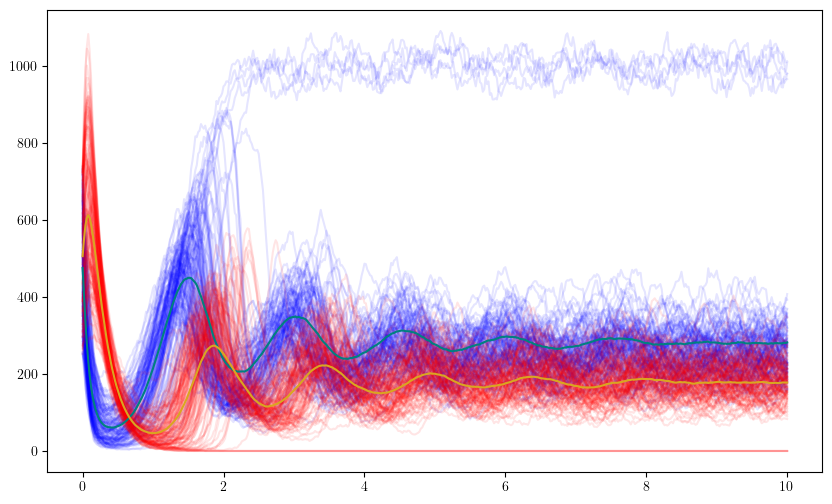

In [7]:
sample_size = 128
width = 500
shift = 250
ic = np.random.choice(width,size = (sample_size,2)) + shift
true_params = [5,0.02,5,1]
alpha,beta,gamma,delta = list(true_params)
t_max = 10
dt = 0.02

times,data = lv_tau_leaping(ic,t_max,true_params)

prey = data[:,:,0]
pred = data[:,:,1]
mprey = np.mean(prey,axis=0)
mpred = np.mean(pred,axis=0)

fig,ax = plt.subplots(figsize=(10,6))
ax.plot(times,prey.T,color = 'blue',alpha = 0.1)
ax.plot(times,pred.T,color = 'red',alpha = 0.1)
ax.plot(times,mprey.T,color = 'teal',alpha = 1)
ax.plot(times,mpred.T,color = 'goldenrod',alpha = 1)

In [ ]:
###### Define things for SMC ABC
## Estimation Parameters
alpha = 0.5
num_particles = 500
cores = 4


def model(p,Bi):
    params = list(p) + [delta]
    obs = data[Bi,:,:]
    _,sim = lv_tau_leaping(ic[Bi,:],t_max,params,dt = 0.02)
    return sim, obs


prior = utils.uniform_prior([[0.01,28.0],[0.0001,0.1],[0.01,28.0]])


def stats_func_lv(x, trunc_ind=200):
    r = x[:, trunc_ind:, 0]
    f = x[:, trunc_ind:, 1]
    
    mu_r = np.mean(r, axis=1)
    mu_f = np.mean(f, axis=1)
    
    # Use Log Coefficient of Variation to break collinearity with the mean
    # std / mean provides a 'unitless' measure of noise
    cv_r = np.log(np.std(r, axis=1) / (mu_r + 1e-5) + 1e-5)
    
    # Correlation (already unitless, keep as is)
    def get_row_corr(a, b):
        ma = a - np.mean(a, axis=1, keepdims=True)
        mb = b - np.mean(b, axis=1, keepdims=True)
        num = np.sum(ma * mb, axis=1)
        den = np.sqrt(np.sum(ma**2, axis=1) * np.sum(mb**2, axis=1))
        return num / (den + 1e-8)

    corr_rf = get_row_corr(r, f)
    
    # ACF_1 is excellent for alpha, and is also unitless
    r_t0, r_t1 = r[:, :-1], r[:, 1:]
    acf_r = get_row_corr(r_t0, r_t1)

    # 5 Statistics total
    features = np.column_stack([
        np.log(mu_r + 1), # Log-transform means to compress scale
        np.log(mu_f + 1),
        cv_r,
        corr_rf,
        acf_r
    ])
    
    return features

def stats_func(x,y,sf = stats_func_lv):
    sx = sf(x)
    sy = sf(y)
    return sx,sy


### AUX
## Stopping criterion
threshold = 5
time_threshold = np.inf
accept_threshold = 0
def threshold_stop(est,threshold = 1,time_threshold=np.inf,accept_threshold=0.0):
    criteria = stop(est,"current_alpha_threshold",threshold) \
        and stop(est,"total_time",time_threshold,compare=lambda x,y: x >= y) \
        and stop(est,"acceptance_rate",accept_threshold)
    return criteria
def stop(est,attribute_name,threshold = 0.025,compare = lambda x,y : x < y):
    if compare(getattr(est,attribute_name),threshold):
        return False
    else:
        return True
stop_func = lambda est: threshold_stop(est, threshold = threshold,time_threshold=time_threshold,accept_threshold=accept_threshold)


######## This makes a dictionary of information shared with the adaptive minibatch schemes
init_params = {
    'data':data,
    'model':model,
    'stats_func':stats_func,
    'prior':prior,
    'num_particles':num_particles,
    'cores':cores,
    'alpha':alpha,
    'batch_size_min':2,
    'batch_size':sample_size,
    'sample_size':sample_size,
}

[[ 5.51867965  5.22697837 -1.49140367 -0.16938016  0.9895257 ]
 [ 5.54023377  5.23589399 -2.08924619 -0.13684673  0.97206931]
 [ 5.50627645  5.22738859 -1.6892405  -0.21171413  0.98260895]
 [ 5.57172445  5.26586968 -1.16943876 -0.18085062  0.99153653]
 [ 5.5194922   5.20331279 -1.72832563 -0.20498124  0.98366706]
 [ 5.51798645  5.27097007 -1.69149133 -0.21384556  0.98381209]
 [ 5.53719038  5.21508019 -1.68262605 -0.05733951  0.98303804]
 [ 5.49882798  5.18232467 -1.60117735 -0.178374    0.98680295]
 [ 5.58025623  5.19347351 -1.3664119  -0.12882798  0.9892083 ]
 [ 5.51000687  5.2048825  -1.45466487 -0.16914707  0.98922727]
 [ 5.59941814  5.15194642 -1.21335075 -0.16547529  0.9919447 ]
 [ 5.51719936  5.23270629 -1.34235725 -0.14436775  0.98992213]
 [ 5.4808327   5.25586753 -1.71346908 -0.0917225   0.98303645]
 [ 5.5142322   5.22865389 -1.82789193 -0.1187272   0.98326999]
 [ 5.50898474  5.18336877 -1.3385522  -0.05260606  0.99028758]
 [ 5.56158845  5.25931058 -1.38282744 -0.1986593   0.99